<a href="https://colab.research.google.com/github/sulucay01/DI725-assignment1/blob/dev/notebooks/03_modeling_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Imports

In [13]:
import os
import random
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, classification_report, confusion_matrix
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    set_seed
)

import wandb

## Reproducibility

In [15]:
SEED = 42
MODEL_NAME = "roberta-base"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

if torch.backends.cudnn.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print("Seed set to:", SEED)
print("CUDA available:", torch.cuda.is_available())

Seed set to: 42
CUDA available: True


## Load processed data

In [16]:
train_df = pd.read_csv("https://raw.githubusercontent.com/sulucay01/DI725-assignment1/dev/data/processed/train_processed.csv")
val_df = pd.read_csv("https://raw.githubusercontent.com/sulucay01/DI725-assignment1/dev/data/processed/val_processed.csv")
test_df = pd.read_csv("https://raw.githubusercontent.com/sulucay01/DI725-assignment1/dev/data/processed/test_processed.csv")

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (773, 16)
Val shape: (194, 16)
Test shape: (30, 16)


In [17]:
required_cols = ["clean_text", "label", "customer_sentiment"]

for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"\n{name.upper()}")
    print("Missing required columns:", [c for c in required_cols if c not in df.columns])
    print("Null clean_text:", df["clean_text"].isna().sum())
    print("Empty clean_text:", (df["clean_text"].fillna("").str.strip() == "").sum())
    print("Label distribution:")
    print(df["customer_sentiment"].value_counts(normalize=True))


TRAIN
Missing required columns: []
Null clean_text: 0
Empty clean_text: 0
Label distribution:
customer_sentiment
neutral     0.560155
negative    0.421734
positive    0.018111
Name: proportion, dtype: float64

VAL
Missing required columns: []
Null clean_text: 0
Empty clean_text: 0
Label distribution:
customer_sentiment
neutral     0.561856
negative    0.422680
positive    0.015464
Name: proportion, dtype: float64

TEST
Missing required columns: []
Null clean_text: 0
Empty clean_text: 0
Label distribution:
customer_sentiment
negative    0.333333
neutral     0.333333
positive    0.333333
Name: proportion, dtype: float64


In [18]:
train_df.head()

,issue_area,issue_category,issue_sub_category,issue_category_sub_category,customer_sentiment,product_category,product_sub_category,issue_complexity,agent_experience_level,agent_experience_level_desc,conversation,clean_text,char_len,word_len,line_count,label
0,Order,Miscellaneous,Estimated delivery time,Miscellaneous -> Estimated delivery time,negative,Electronics,Power Bank,less,inexperienced,"may struggle with ambiguous queries, rely on c...","Agent: Hello, thank you for contacting BrownBo...","[AGENT] Hello, thank you for contacting BrownB...",2286,419,17,0
1,Cancellations and returns,Return and Exchange,Refund timelines for cancellation or returns,Return and Exchange -> Refund timelines for ca...,neutral,Men/Women/Kids,Toy,medium,experienced,"confidently handles complex customer issues, e...","Customer: Hi, I need help with returning a toy...","[CUSTOMER] Hi, I need help with returning a to...",2100,359,22,1
2,Order,Order Delivery Issues,Order approved but not shipped,Order Delivery Issues -> Order approved but no...,negative,Appliances,Ceiling Fan,medium,junior,"handles customer inquiries independently, poss...","Customer: Hello, I'm calling about my order fo...","[CUSTOMER] Hello, I'm calling about my order f...",2708,473,24,0
3,Cancellations and returns,Pickup and Shipping,Reasons for being asked to ship the item,Pickup and Shipping -> Reasons for being asked...,neutral,Appliances,Washing Machine,less,junior,"handles customer inquiries independently, poss...","Customer: Hi, I received an email from BrownBo...","[CUSTOMER] Hi, I received an email from BrownB...",2123,373,16,1
4,Cancellations and returns,Cash on Delivery (CoD) Refunds,Refund process for items paid for with Cash on...,Cash on Delivery (CoD) Refunds -> Refund proce...,neutral,Appliances,Sandwich Maker,less,experienced,"confidently handles complex customer issues, e...","Agent: Hello, thank you for calling BrownBox c...","[AGENT] Hello, thank you for calling BrownBox ...",1947,350,19,1


In [19]:
for df in [train_df, val_df, test_df]:
    df["clean_text"] = df["clean_text"].fillna("").astype(str)

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

print("\nTokenizer loaded:", MODEL_NAME)
print("Tokenizer model_max_length:", tokenizer.model_max_length)

Train shape: (773, 16)
Val shape: (194, 16)
Test shape: (30, 16)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


Tokenizer loaded: roberta-base
Tokenizer model_max_length: 512


In [20]:
def get_token_lengths(texts, tokenizer):
    lengths = []
    for text in texts:
        enc = tokenizer(
            text,
            add_special_tokens=True,
            truncation=False,
            padding=False
        )
        lengths.append(len(enc["input_ids"]))
    return lengths

train_lengths = get_token_lengths(train_df["clean_text"], tokenizer)
val_lengths = get_token_lengths(val_df["clean_text"], tokenizer)
test_lengths = get_token_lengths(test_df["clean_text"], tokenizer)

Token indices sequence length is longer than the specified maximum sequence length for this model (579 > 512). Running this sequence through the model will result in indexing errors


In [21]:
def summarize_lengths(lengths, split_name):
    arr = np.array(lengths)

    print(f"\n===== {split_name.upper()} TOKEN LENGTH SUMMARY =====")
    print(f"count:   {len(arr)}")
    print(f"min:     {arr.min()}")
    print(f"mean:    {arr.mean():.2f}")
    print(f"median:  {np.median(arr):.2f}")
    print(f"p90:     {np.percentile(arr, 90):.2f}")
    print(f"p95:     {np.percentile(arr, 95):.2f}")
    print(f"p99:     {np.percentile(arr, 99):.2f}")
    print(f"max:     {arr.max()}")

summarize_lengths(train_lengths, "train")
summarize_lengths(val_lengths, "val")
summarize_lengths(test_lengths, "test")


===== TRAIN TOKEN LENGTH SUMMARY =====
count:   773
min:     197
mean:    544.27
median:  528.00
p90:     710.60
p95:     775.20
p99:     915.04
max:     1381

===== VAL TOKEN LENGTH SUMMARY =====
count:   194
min:     267
mean:    552.63
median:  518.50
p90:     753.40
p95:     841.00
p99:     953.31
max:     1099

===== TEST TOKEN LENGTH SUMMARY =====
count:   30
min:     296
mean:    559.73
median:  521.00
p90:     732.90
p95:     802.60
p99:     1193.80
max:     1333


In [22]:
def truncation_report(lengths, split_name, candidates=(128, 256, 384, 512)):
    arr = np.array(lengths)

    print(f"\n===== {split_name.upper()} TRUNCATION REPORT =====")
    for max_len in candidates:
        truncated = (arr > max_len).sum()
        rate = truncated / len(arr) * 100
        print(f"max_length={max_len:<3} -> truncated: {truncated:>5} / {len(arr)} ({rate:.2f}%)")

truncation_report(train_lengths, "train")
truncation_report(val_lengths, "val")
truncation_report(test_lengths, "test")


===== TRAIN TRUNCATION REPORT =====
max_length=128 -> truncated:   773 / 773 (100.00%)
max_length=256 -> truncated:   770 / 773 (99.61%)
max_length=384 -> truncated:   720 / 773 (93.14%)
max_length=512 -> truncated:   427 / 773 (55.24%)

===== VAL TRUNCATION REPORT =====
max_length=128 -> truncated:   194 / 194 (100.00%)
max_length=256 -> truncated:   194 / 194 (100.00%)
max_length=384 -> truncated:   183 / 194 (94.33%)
max_length=512 -> truncated:   102 / 194 (52.58%)

===== TEST TRUNCATION REPORT =====
max_length=128 -> truncated:    30 / 30 (100.00%)
max_length=256 -> truncated:    30 / 30 (100.00%)
max_length=384 -> truncated:    25 / 30 (83.33%)
max_length=512 -> truncated:    18 / 30 (60.00%)


In [23]:
train_df = train_df.copy()
train_df["token_length"] = train_lengths

longest_examples = train_df.sort_values("token_length", ascending=False)[
    ["clean_text", "customer_sentiment", "token_length"]
].head(10)

pd.set_option("display.max_colwidth", 300)
longest_examples

,clean_text,customer_sentiment,token_length
418,"[AGENT] Thank you for calling BrownBox Customer Support. This is John. How can I assist you today?\n[CUSTOMER] Hi John, I want to cancel my order for a tablet. I received it, but it's not working correctly.\n[AGENT] I'm sorry to hear that. May I have your order number and the phone number associ...",negative,1381
241,"[AGENT] Thank you for contacting BrownBox customer support. My name is Sarah. How can I assist you today?\n[CUSTOMER] Hi Sarah. I recently purchased a washing machine from your website, but it's not working as expected. I want to return or exchange it.\n[AGENT] I apologize for the inconvenience,...",neutral,1150
442,"[CUSTOMER] Hi, I was trying to purchase an Oven Toaster Grills (OTG) from your website, but it says that faster delivery options are not available for my location. Is there any way I can get it delivered faster?\n[AGENT] Hello! Thank you for contacting BrownBox customer support. My name is John,...",negative,1029
253,"[AGENT] Thank you for calling BrownBox Customer Support. This is Sarah. How may I assist you today?\n[CUSTOMER] Hi Sarah, I am trying to purchase a washing machine, and I need it urgently. However, I am not able to find any faster delivery options for my location.\n[AGENT] I'm sorry to hear that...",negative,993
555,"[AGENT] Thank you for calling BrownBox Customer Support. My name is Alex. How may I assist you today?\n[CUSTOMER] Hi, Alex. I recently purchased a Juicer/Mixer/Grinder from your website, but it's not working properly. I would like to return it and get a replacement.\n[AGENT] I'm sorry to hear th...",neutral,973
567,"[AGENT] Thank you for calling BrownBox Customer Support. My name is John. How may I assist you today?\n[CUSTOMER] Hi John, I'm trying to order a smartwatch, but it says that the product is not available for shipping to my location.\n[AGENT] I'm sorry to hear that. May I know your location and th...",negative,973
471,"[AGENT] Hello, thank you for calling BrownBox Customer Support. My name is Sarah, how may I assist you today?\n[CUSTOMER] Hi, I am trying to order a refrigerator from your website, but it says it's not available for shipping to my location. What's the issue here?\n[AGENT] I'm sorry to hear that....",negative,970
395,"[AGENT] Thank you for calling BrownBox Customer Support. My name is Sarah. How may I assist you today?\n[CUSTOMER] Hi, Sarah. I recently purchased a Vacuum Cleaner from your website, but it's not working correctly. I would like to return it.\n[AGENT] I'm sorry to hear that. May I know your order...",negative,946
60,"[AGENT] Thank you for calling BrownBox Customer Support. My name is John. How may I assist you today?\n[CUSTOMER] Hi John, I am trying to log in with my mobile number on the mobile app for an Electric Cooker, but I am unable to do so.\n[AGENT] I'm sorry to hear that, and I'll be happy to assist ...",neutral,903
501,"[AGENT] Thank you for calling BrownBox Customer Support. This is Sarah. How can I assist you today?\n[CUSTOMER] Hi Sarah, I need to change the address for the pickup of my computer monitor. The current address is incorrect, and I won't be able to receive the item there.\n[AGENT] I'm sorry to hea...",negative,900


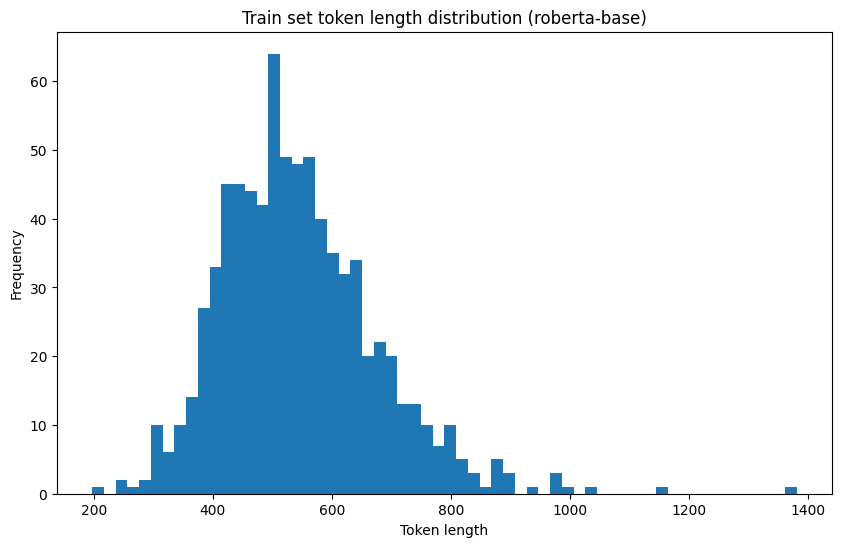

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(train_lengths, bins=60)
plt.xlabel("Token length")
plt.ylabel("Frequency")
plt.title("Train set token length distribution (roberta-base)")
plt.show()

In [ ]:
# -*- coding: utf-8 -*-
"""03_modeling_fusion_features.ipynb

Text + structured feature fusion model for customer sentiment classification.

This notebook:
1. loads processed datasets from GitHub (dev branch)
2. creates stronger behavioral and ending-based features
3. prepares tokenized text + scaled numeric features
4. trains a RoBERTa fusion classifier
5. evaluates on validation and test sets
"""

# =========================================================
# 1. Imports
# =========================================================

import os
import re
import json
import math
import random
import requests
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

from transformers import (
    AutoTokenizer,
    AutoModel,
    get_linear_schedule_with_warmup
)

from torch.optim import AdamW

# =========================================================
# 2. Reproducibility
# =========================================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# =========================================================
# 3. Basic settings
# =========================================================

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 300)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

MODEL_NAME = "roberta-base"
MAX_LENGTH = 256
BATCH_SIZE = 8
EPOCHS = 5
LR = 2e-5
WEIGHT_DECAY = 0.01
DROPOUT = 0.30

os.makedirs("outputs_fusion", exist_ok=True)
os.makedirs("outputs_fusion/predictions", exist_ok=True)
os.makedirs("outputs_fusion/models", exist_ok=True)

# =========================================================
# 4. Load processed data from GitHub dev branch
# =========================================================

BASE_URL = "https://raw.githubusercontent.com/sulucay01/DI725-assignment1/dev/data/processed"

train_df = pd.read_csv(f"{BASE_URL}/train_processed.csv")
val_df   = pd.read_csv(f"{BASE_URL}/val_processed.csv")
test_df  = pd.read_csv(f"{BASE_URL}/test_processed.csv")

label_mapping = requests.get(f"{BASE_URL}/label_mapping.json").json()

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)
print("\nLabel mapping:", label_mapping)

id2label = {int(v): k for k, v in label_mapping.items()}
label2id = {k: int(v) for k, v in label_mapping.items()}
num_labels = len(label2id)

# =========================================================
# 5. Better feature engineering
# =========================================================

STRONG_POSITIVE_PATTERNS = [
    "that works",
    "works now",
    "working now",
    "issue resolved",
    "problem solved",
    "that fixed it",
    "fixed now",
    "all set",
    "thank you so much",
    "appreciate your help",
    "really helpful",
    "great support",
    "perfect",
    "awesome",
    "resolved now"
]

STRONG_NEGATIVE_PATTERNS = [
    "still not working",
    "not working",
    "doesn't work",
    "does not work",
    "not fixed",
    "same issue",
    "same problem",
    "still having",
    "still facing",
    "again",
    "this is frustrating",
    "frustrating",
    "not helpful",
    "worst",
    "refund",
    "cancel"
]

POLITE_CLOSING_PATTERNS = [
    "goodbye",
    "bye",
    "you too",
    "have a good day",
    "have a great day",
    "thank you",
    "thanks"
]

QUESTION_HINTS = [
    "why", "how", "what", "when", "where", "can you", "could you"
]

def safe_text(x):
    return str(x) if pd.notnull(x) else ""

def contains_any_pattern(text, patterns):
    text = safe_text(text).lower()
    return int(any(p in text for p in patterns))

def count_any_pattern(text, patterns):
    text = safe_text(text).lower()
    return sum(int(p in text) for p in patterns)

def get_last_customer_message(text):
    """
    Extract only the text spoken by the final customer turn.
    Keeps content after the last [CUSTOMER] and cuts before the next [AGENT], if any.
    """
    text = safe_text(text)

    if "[CUSTOMER]" not in text:
        return text.strip()

    last_part = text.split("[CUSTOMER]")[-1]

    if "[AGENT]" in last_part:
        last_part = last_part.split("[AGENT]")[0]

    return last_part.strip()

def get_last_agent_message(text):
    """
    Extract only the text spoken by the final agent turn.
    """
    text = safe_text(text)

    if "[AGENT]" not in text:
        return ""

    last_part = text.split("[AGENT]")[-1]

    if "[CUSTOMER]" in last_part:
        last_part = last_part.split("[CUSTOMER]")[0]

    return last_part.strip()

def get_last_n_chars(text, n=600):
    text = safe_text(text)
    return text[-n:]

def classify_ending_type(last_customer_msg):
    """
    2 = clearly resolved / positive ending
    1 = polite / neutral ending
    0 = unresolved / negative ending
    """
    text = safe_text(last_customer_msg).lower()

    if any(p in text for p in STRONG_POSITIVE_PATTERNS):
        return 2
    elif any(p in text for p in STRONG_NEGATIVE_PATTERNS):
        return 0
    else:
        return 1

def add_behavioral_features(df):
    df = df.copy()

    # Base text
    df["clean_text"] = df["clean_text"].astype(str)

    # Turn counts
    df["num_customer_turns"] = df["clean_text"].apply(lambda x: x.count("[CUSTOMER]"))
    df["num_agent_turns"] = df["clean_text"].apply(lambda x: x.count("[AGENT]"))
    df["turn_ratio"] = df["num_customer_turns"] / (df["num_agent_turns"] + 1)

    # Last messages
    df["last_customer_msg"] = df["clean_text"].apply(get_last_customer_message)
    df["last_agent_msg"] = df["clean_text"].apply(get_last_agent_message)

    # Tail text
    df["tail_text"] = df["clean_text"].apply(lambda x: get_last_n_chars(x, n=800))

    # Length features
    df["last_customer_len"] = df["last_customer_msg"].apply(len)
    df["last_agent_len"] = df["last_agent_msg"].apply(len)
    df["tail_len"] = df["tail_text"].apply(len)

    # Strong pattern features
    df["has_strong_positive"] = df["clean_text"].apply(lambda x: contains_any_pattern(x, STRONG_POSITIVE_PATTERNS))
    df["has_strong_negative"] = df["clean_text"].apply(lambda x: contains_any_pattern(x, STRONG_NEGATIVE_PATTERNS))

    df["ending_has_strong_positive"] = df["last_customer_msg"].apply(lambda x: contains_any_pattern(x, STRONG_POSITIVE_PATTERNS))
    df["ending_has_strong_negative"] = df["last_customer_msg"].apply(lambda x: contains_any_pattern(x, STRONG_NEGATIVE_PATTERNS))

    df["polite_closing"] = df["last_customer_msg"].apply(lambda x: contains_any_pattern(x, POLITE_CLOSING_PATTERNS))
    df["ending_has_question"] = df["last_customer_msg"].str.contains(r"\?", regex=True).astype(int)

    # Counts
    df["thanks_count"] = df["clean_text"].str.lower().str.count(r"\bthank\b|\bthanks\b")
    df["question_count"] = df["clean_text"].str.count(r"\?")
    df["exclamation_count"] = df["clean_text"].str.count(r"!")
    df["positive_pattern_count"] = df["clean_text"].apply(lambda x: count_any_pattern(x, STRONG_POSITIVE_PATTERNS))
    df["negative_pattern_count"] = df["clean_text"].apply(lambda x: count_any_pattern(x, STRONG_NEGATIVE_PATTERNS))

    # Ending type
    df["ending_type"] = df["last_customer_msg"].apply(classify_ending_type)

    # Simple resolution / unresolved signals
    df["still_signal"] = df["clean_text"].str.lower().str.contains(r"\bstill\b").astype(int)
    df["again_signal"] = df["clean_text"].str.lower().str.contains(r"\bagain\b").astype(int)
    df["refund_signal"] = df["clean_text"].str.lower().str.contains(r"\brefund\b").astype(int)
    df["cancel_signal"] = df["clean_text"].str.lower().str.contains(r"\bcancel\b").astype(int)

    # A cleaner text input candidate for the model:
    # last portion of the conversation + last customer message emphasis
    df["model_text"] = (
    "[LAST_CUSTOMER] " + df["last_customer_msg"] +
    " [LAST_AGENT] " + df["last_agent_msg"] +
    " [TAIL] " + df["tail_text"]
)
    return df

train_df = add_behavioral_features(train_df)
val_df = add_behavioral_features(val_df)
test_df = add_behavioral_features(test_df)

print("\nFeature columns added successfully.")
print(train_df.head(2))

# =========================================================
# 6. Quick feature inspection
# =========================================================

feature_cols = [
    "char_len", "word_len", "line_count",
    "num_customer_turns", "num_agent_turns", "turn_ratio",
    "last_customer_len", "last_agent_len", "tail_len",
    "has_strong_positive", "has_strong_negative",
    "ending_has_strong_positive", "ending_has_strong_negative",
    "polite_closing", "ending_has_question",
    "thanks_count", "question_count", "exclamation_count",
    "positive_pattern_count", "negative_pattern_count",
    "ending_type", "still_signal", "again_signal",
    "refund_signal", "cancel_signal"
]

print("\nGrouped feature means:")
print(train_df.groupby("customer_sentiment")[feature_cols].mean().round(3))

print("\nSample positive endings:")
positive_examples = train_df[train_df["customer_sentiment"].str.lower() == "positive"]["last_customer_msg"].head(10)
for x in positive_examples:
    print("\n---")
    print(x[:500])



Using device: cuda
Train shape: (773, 16)
Val shape: (194, 16)
Test shape: (30, 15)

Label mapping: {'negative': 0, 'neutral': 1, 'positive': 2}

Feature columns added successfully.
                  issue_area       issue_category  \
0                      Order        Miscellaneous   
1  Cancellations and returns  Return and Exchange   

                             issue_sub_category  \
0                       Estimated delivery time   
1  Refund timelines for cancellation or returns   

                                           issue_category_sub_category  \
0                             Miscellaneous -> Estimated delivery time   
1  Return and Exchange -> Refund timelines for cancellation or returns   

  customer_sentiment product_category product_sub_category issue_complexity  \
0           negative      Electronics           Power Bank             less   
1            neutral   Men/Women/Kids                  Toy           medium   

  agent_experience_level  \
0          inex

In [ ]:
# =========================================================
# 7. Select final structured features
# =========================================================

numeric_feature_cols = [
    # structure
    #"char_len",
    "word_len",
    "line_count",
    "num_customer_turns",
    #"num_agent_turns",
    #"turn_ratio",

    # strong signals
    "has_strong_positive",
    "has_strong_negative",
    "positive_pattern_count",
    "negative_pattern_count",

    # behavioral
    "still_signal",
    "again_signal",
    "refund_signal",
    "cancel_signal",

    # ending behavior
    #"ending_type"
]

TEXT_COL = "model_text"
LABEL_COL = "label"

# =========================================================
# 8. Scale numeric features
# =========================================================

scaler = StandardScaler()

X_train_num = scaler.fit_transform(train_df[numeric_feature_cols])
X_val_num = scaler.transform(val_df[numeric_feature_cols])
X_test_num = scaler.transform(test_df[numeric_feature_cols])

train_num_df = pd.DataFrame(X_train_num, columns=numeric_feature_cols)
val_num_df = pd.DataFrame(X_val_num, columns=numeric_feature_cols)
test_num_df = pd.DataFrame(X_test_num, columns=numeric_feature_cols)

print("\nScaled feature shapes:")
print(train_num_df.shape, val_num_df.shape, test_num_df.shape)

# =========================================================
# 9. Tokenizer
# =========================================================

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# =========================================================
# 10. Custom dataset
# =========================================================

class FusionTextDataset(Dataset):
    def __init__(self, df, numeric_features, tokenizer, text_col, label_col=None, max_length=256):
        self.df = df.reset_index(drop=True)
        self.numeric_features = np.asarray(numeric_features, dtype=np.float32)
        self.tokenizer = tokenizer
        self.text_col = text_col
        self.label_col = label_col
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        text = str(self.df.loc[idx, self.text_col])

        encoded = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        item = {
            "input_ids": encoded["input_ids"].squeeze(0),
            "attention_mask": encoded["attention_mask"].squeeze(0),
            "features": torch.tensor(self.numeric_features[idx], dtype=torch.float)
        }

        if self.label_col is not None and self.label_col in self.df.columns:
            item["labels"] = torch.tensor(int(self.df.loc[idx, self.label_col]), dtype=torch.long)

        return item

train_dataset = FusionTextDataset(
    train_df, X_train_num, tokenizer, text_col=TEXT_COL, label_col=LABEL_COL, max_length=MAX_LENGTH
)

val_dataset = FusionTextDataset(
    val_df, X_val_num, tokenizer, text_col=TEXT_COL, label_col=LABEL_COL, max_length=MAX_LENGTH
)

test_has_labels = LABEL_COL in test_df.columns

test_dataset = FusionTextDataset(
    test_df, X_test_num, tokenizer, text_col=TEXT_COL,
    label_col=LABEL_COL if test_has_labels else None,
    max_length=MAX_LENGTH
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# =========================================================
# 11. Fusion model
# =========================================================

class RobertaFusionClassifier(nn.Module):
    def __init__(self, model_name, num_numeric_features, num_labels, dropout=0.3):
        super().__init__()

        self.text_encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.text_encoder.config.hidden_size  # 768 for roberta-base

        self.feature_proj = nn.Sequential(
            nn.Linear(num_numeric_features, 64),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size + 64, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_labels)
        )

    def forward(self, input_ids, attention_mask, features):
        outputs = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)

        # RoBERTa has no true CLS token in the same BERT sense, but first token hidden state is commonly used
        pooled_text = outputs.last_hidden_state[:, 0, :]

        projected_features = self.feature_proj(features)

        fused = torch.cat([pooled_text, projected_features], dim=1)
        logits = self.classifier(fused)

        return logits

model = RobertaFusionClassifier(
    model_name=MODEL_NAME,
    num_numeric_features=len(numeric_feature_cols),
    num_labels=num_labels,
    dropout=DROPOUT
)

model.to(DEVICE)

# =========================================================
# 12. Loss, optimizer, scheduler
# =========================================================

# Optional: class weights to help minority class
class_counts = train_df[LABEL_COL].value_counts().sort_index().values
class_weights = len(train_df) / (num_labels * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)

print("\nClass counts:", class_counts)
print("Class weights:", class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

# =========================================================
# 13. Utility functions
# =========================================================

def compute_metrics_from_preds(y_true, y_pred):
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    acc = accuracy_score(y_true, y_pred)

    return {
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted
    }

def run_epoch(model, loader, optimizer=None, scheduler=None, train_mode=True):
    if train_mode:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []
    all_logits = []

    for batch in loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        features = batch["features"].to(DEVICE)

        labels = batch.get("labels")
        if labels is not None:
            labels = labels.to(DEVICE)

        if train_mode:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train_mode):
            logits = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                features=features
            )

            if labels is not None:
                loss = criterion(logits, labels)
            else:
                loss = None

            if train_mode and loss is not None:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                if scheduler is not None:
                    scheduler.step()

        if loss is not None:
            total_loss += loss.item()

        preds = torch.argmax(logits, dim=1).detach().cpu().numpy()
        all_preds.extend(preds.tolist())
        all_logits.append(logits.detach().cpu().numpy())

        if labels is not None:
            all_labels.extend(labels.detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(loader) if len(loader) > 0 else None
    all_logits = np.concatenate(all_logits, axis=0)

    if len(all_labels) > 0:
        metrics = compute_metrics_from_preds(all_labels, all_preds)
    else:
        metrics = {}

    return avg_loss, metrics, np.array(all_preds), np.array(all_labels), all_logits

# =========================================================
# 14. Training loop
# =========================================================

best_val_f1 = -1
best_model_path = "outputs_fusion/models/best_fusion_model.pt"
history = []

for epoch in range(EPOCHS):
    print(f"\n{'='*60}")
    print(f"Epoch {epoch+1}/{EPOCHS}")

    train_loss, train_metrics, _, _, _ = run_epoch(
        model, train_loader, optimizer=optimizer, scheduler=scheduler, train_mode=True
    )

    val_loss, val_metrics, val_preds, val_labels, val_logits = run_epoch(
        model, val_loader, optimizer=None, scheduler=None, train_mode=False
    )

    print("\nTrain loss:", round(train_loss, 4))
    print("Train metrics:", {k: round(v, 4) for k, v in train_metrics.items()})

    print("\nVal loss:", round(val_loss, 4))
    print("Val metrics:", {k: round(v, 4) for k, v in val_metrics.items()})

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        **{f"train_{k}": v for k, v in train_metrics.items()},
        "val_loss": val_loss,
        **{f"val_{k}": v for k, v in val_metrics.items()}
    })

    if val_metrics["f1_macro"] > best_val_f1:
        best_val_f1 = val_metrics["f1_macro"]
        torch.save(model.state_dict(), best_model_path)
        print("Saved new best model.")

history_df = pd.DataFrame(history)
history_df.to_csv("outputs_fusion/training_history.csv", index=False)

# =========================================================
# 15. Load best model
# =========================================================

model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()

print("\nBest validation f1_macro:", round(best_val_f1, 4))

# =========================================================
# 16. Validation evaluation
# =========================================================

val_loss, val_metrics, val_preds, val_labels, val_logits = run_epoch(
    model, val_loader, optimizer=None, scheduler=None, train_mode=False
)

print("\nValidation metrics:")
print(val_metrics)

print("\nValidation classification report:")
print(classification_report(
    val_labels,
    val_preds,
    target_names=[id2label[i] for i in range(num_labels)],
    digits=4,
    zero_division=0
))

val_cm = confusion_matrix(val_labels, val_preds)
print("\nValidation confusion matrix:")
print(val_cm)

with open("outputs_fusion/val_metrics.json", "w") as f:
    json.dump(val_metrics, f, indent=4)

np.savetxt("outputs_fusion/val_confusion_matrix.txt", val_cm, fmt="%d")

val_pred_df = val_df.copy()
val_pred_df["pred_label"] = val_preds
val_pred_df["pred_sentiment"] = val_pred_df["pred_label"].map(id2label)
val_pred_df["true_sentiment"] = val_pred_df["label"].map(id2label)

for i in range(num_labels):
    val_pred_df[f"logit_class_{i}"] = val_logits[:, i]

val_pred_df.to_csv("outputs_fusion/predictions/val_predictions.csv", index=False)

# =========================================================
# 17. Test evaluation / prediction
# =========================================================

test_loss, test_metrics, test_preds, test_labels, test_logits = run_epoch(
    model, test_loader, optimizer=None, scheduler=None, train_mode=False
)

if test_has_labels:
    print("\nTest metrics:")
    print(test_metrics)

    print("\nTest classification report:")
    print(classification_report(
        test_labels,
        test_preds,
        target_names=[id2label[i] for i in range(num_labels)],
        digits=4,
        zero_division=0
    ))

    test_cm = confusion_matrix(test_labels, test_preds)
    print("\nTest confusion matrix:")
    print(test_cm)

    with open("outputs_fusion/test_metrics.json", "w") as f:
        json.dump(test_metrics, f, indent=4)

    np.savetxt("outputs_fusion/test_confusion_matrix.txt", test_cm, fmt="%d")

test_pred_df = test_df.copy()
test_pred_df["pred_label"] = test_preds
test_pred_df["pred_sentiment"] = test_pred_df["pred_label"].map(id2label)

for i in range(num_labels):
    test_pred_df[f"logit_class_{i}"] = test_logits[:, i]

test_pred_df.to_csv("outputs_fusion/predictions/test_predictions.csv", index=False)

# =========================================================
# 18. Save model artifacts
# =========================================================

torch.save(model.state_dict(), "outputs_fusion/models/final_fusion_model.pt")
tokenizer.save_pretrained("outputs_fusion/models/tokenizer")

with open("outputs_fusion/models/numeric_feature_cols.json", "w") as f:
    json.dump(numeric_feature_cols, f, indent=4)

print("\nSaved artifacts:")
print("- outputs_fusion/models/best_fusion_model.pt")
print("- outputs_fusion/models/final_fusion_model.pt")
print("- outputs_fusion/models/tokenizer")
print("- outputs_fusion/predictions/val_predictions.csv")
print("- outputs_fusion/predictions/test_predictions.csv")

# =========================================================
# 19. Error analysis
# =========================================================

errors = val_pred_df[val_pred_df["true_sentiment"] != val_pred_df["pred_sentiment"]].copy()
print("\nValidation errors:", len(errors))

display_cols = [
    "clean_text",
    "last_customer_msg",
    "true_sentiment",
    "pred_sentiment",
    "ending_type",
    "has_strong_positive",
    "has_strong_negative",
    "ending_has_strong_positive",
    "ending_has_strong_negative",
    "polite_closing"
]

display(errors[display_cols].head(15))


Scaled feature shapes:
(773, 11) (194, 11) (30, 11)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Class counts: [326 433  14]
Class weights: tensor([ 0.7904,  0.5951, 18.4048], device='cuda:0')

Epoch 1/3

Train loss: 1.0975
Train metrics: {'accuracy': 0.5252, 'precision_macro': 0.3768, 'recall_macro': 0.3684, 'f1_macro': 0.3646, 'precision_weighted': 0.5558, 'recall_weighted': 0.5252, 'f1_weighted': 0.5377}

Val loss: 0.7293
Val metrics: {'accuracy': 0.7732, 'precision_macro': 0.5293, 'recall_macro': 0.5362, 'f1_macro': 0.5194, 'precision_weighted': 0.7982, 'recall_weighted': 0.7732, 'f1_weighted': 0.7661}
Saved new best model.

Epoch 2/3

Train loss: 0.8191
Train metrics: {'accuracy': 0.7891, 'precision_macro': 0.5239, 'recall_macro': 0.5335, 'f1_macro': 0.5286, 'precision_weighted': 0.7748, 'recall_weighted': 0.7891, 'f1_weighted': 0.7819}

Val loss: 0.6654
Val metrics: {'accuracy': 0.8247, 'precision_macro': 0.5586, 'recall_macro': 0.5487, 'f1_macro': 0.5493, 'precision_weighted': 0.819, 'recall_weighted': 0.8247, 'f1_weighted': 0.8157}
Saved new best model.

Epoch 3/3

Train 

,clean_text,last_customer_msg,true_sentiment,pred_sentiment,ending_type,has_strong_positive,has_strong_negative,ending_has_strong_positive,ending_has_strong_negative,polite_closing
3,"[CUSTOMER] Hi, I have an issue with my recent purchase, and I need help with it.\n[AGENT] Hello! I'm sorry to hear that. My name is Sarah, and I'm here to help you. May I have your order number, please?\n[CUSTOMER] Sure, it's [ID].\n[AGENT] Thank you for providing that information. How can I ass...","Thank you, you too. Goodbye!\nSenior",negative,neutral,1,1,1,0,0,1
4,"[AGENT] Thank you for calling BrownBox Customer Support. My name is John. How can I assist you today?\n[CUSTOMER] Hi John, I'm having trouble with the verification code for my vacuum cleaner purchase. I've been trying to receive the OTP for the past hour, and I haven't received it yet.\n[AGENT] ...","No, that's all. Thank you for your help.",negative,neutral,1,0,1,0,0,1
24,"[AGENT] Thank you for calling BrownBox Customer Support. My name is Sarah. How may I assist you today?\n[CUSTOMER] Hi Sarah, I received a damaged pram/stroller that I ordered from your website. The packaging was not good enough to protect it during transit.\n[AGENT] I'm sorry to hear that. May I...","Thanks, you too. Goodbye.",negative,neutral,1,0,1,0,0,1
27,"[CUSTOMER] Hi, I am trying to find my invoice for the mobile I purchased from BrownBox, but I can't seem to locate it.\n[AGENT] Hello, thank you for contacting BrownBox customer support. My name is Sarah. Can you please provide me with your name and order number?\n[CUSTOMER] My name is Jane and ...",You too. Goodbye.,neutral,negative,1,0,0,0,0,1
31,"[AGENT] Thank you for calling BrownBox Customer Support. My name is Emily. How may I assist you today?\n[CUSTOMER] Hi Emily, I recently purchased a Sandwich Maker from your website, but I lost the warranty card. The product is no longer working, and I need to claim the warranty. Can you help me ...",You too. Goodbye!,negative,neutral,1,1,0,0,0,1
39,"[CUSTOMER] Hi, I'm calling because I am interested in purchasing a Kitchen Chimney from BrownBox, but I am unable to find the seller's returns policy.\n[AGENT] Hi there! My name is Sarah, and I'll be happy to assist you with your inquiry. Can you please provide me with the name or product code o...","No, that's all. Thank you for your help.",positive,neutral,1,0,1,0,0,1
43,"[AGENT] Hello, thank you for calling BrownBox customer support. My name is Alex. How may I assist you today?\n[CUSTOMER] Hi Alex, I recently purchased a T-shirt from your website and I'm trying to find the seller's returns policy. Can you help me with that?\n[AGENT] Sure, I can definitely help w...","You too, bye.",positive,neutral,1,0,1,0,0,1
44,"[CUSTOMER] Hello, I'm trying to log in to my BrownBox account to purchase a Wet Grinder, but it's asking me to verify my mobile number or email address. Why do I need to do that?\n[AGENT] Good afternoon! Thank you for contacting BrownBox customer support. My name is Sarah, and I'm here to assist...","You too, Sarah. Goodbye!",neutral,negative,1,0,1,0,0,1
48,"[AGENT] Thank you for calling BrownBox Customer Support. My name is Sarah. How may I assist you today?\n[CUSTOMER] Hi Sarah, I received a mobile phone from your company, and the package was open and tampered with on delivery. I am very unhappy about this.\n[AGENT] I am sorry to hear that, sir. I...","No, that's all. Thank you again for your assistance.",negative,neutral,0,1,1,0,1,1
52,"[AGENT] Thank you for calling BrownBox Customer Support. My name is Lily. How may I assist you today?\n[CUSTOMER] Hi Lily, I received a toy from your website, but it's not what I expected. I want to return it and get a refund.\n[AGENT] I'm sorry to hear that, may I have your name and order numbe...","No, that's all for now. Thanks again.",negative,neutral,0,0,1,0,1,1


In [ ]:
# -*- coding: utf-8 -*-
"""03_modeling_fusion_text_numeric_categorical.ipynb

Fusion model for customer sentiment classification.

Uses:
1. RoBERTa text encoder
2. Strong engineered numeric features
3. Learned embeddings for issue_area and issue_category

Data source:
- processed CSVs from GitHub dev branch
"""

# =========================================================
# 1. Imports
# =========================================================

import os
import re
import json
import random
import requests
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

from transformers import (
    AutoTokenizer,
    AutoModel,
    get_linear_schedule_with_warmup
)

from torch.optim import AdamW

# =========================================================
# 2. Reproducibility
# =========================================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# =========================================================
# 3. Settings
# =========================================================

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 300)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

MODEL_NAME = "roberta-base"
MAX_LENGTH = 256
BATCH_SIZE = 8
EPOCHS = 6
LR = 2e-5
WEIGHT_DECAY = 0.01
DROPOUT = 0.35

os.makedirs("outputs_fusion_v2", exist_ok=True)
os.makedirs("outputs_fusion_v2/predictions", exist_ok=True)
os.makedirs("outputs_fusion_v2/models", exist_ok=True)

# =========================================================
# 4. Load processed data from GitHub dev branch
# =========================================================

BASE_URL = "https://raw.githubusercontent.com/sulucay01/DI725-assignment1/dev/data/processed"

train_df = pd.read_csv(f"{BASE_URL}/train_processed.csv")
val_df   = pd.read_csv(f"{BASE_URL}/val_processed.csv")
test_df  = pd.read_csv(f"{BASE_URL}/test_processed.csv")

label_mapping = requests.get(f"{BASE_URL}/label_mapping.json").json()

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)
print("\nLabel mapping:", label_mapping)

label2id = {k: int(v) for k, v in label_mapping.items()}
id2label = {int(v): k for k, v in label_mapping.items()}
num_labels = len(label2id)

# =========================================================
# 5. Feature engineering
# =========================================================

STRONG_POSITIVE_PATTERNS = [
    "that works",
    "works now",
    "working now",
    "issue resolved",
    "problem solved",
    "that fixed it",
    "fixed now",
    "all set",
    "appreciate your help",
    "really helpful",
    "great support",
    "perfect",
    "awesome",
    "resolved now"
]

STRONG_NEGATIVE_PATTERNS = [
    "still not working",
    "not working",
    "doesn't work",
    "does not work",
    "not fixed",
    "same issue",
    "same problem",
    "still having",
    "still facing",
    "again",
    "frustrating",
    "not helpful",
    "worst",
    "refund",
    "cancel"
]

def safe_text(x):
    return str(x) if pd.notnull(x) else ""

def contains_any_pattern(text, patterns):
    text = safe_text(text).lower()
    return int(any(p in text for p in patterns))

def count_any_pattern(text, patterns):
    text = safe_text(text).lower()
    return sum(int(p in text) for p in patterns)

def get_last_customer_message(text):
    text = safe_text(text)
    if "[CUSTOMER]" not in text:
        return text.strip()
    last_part = text.split("[CUSTOMER]")[-1]
    if "[AGENT]" in last_part:
        last_part = last_part.split("[AGENT]")[0]
    return last_part.strip()

def get_last_agent_message(text):
    text = safe_text(text)
    if "[AGENT]" not in text:
        return ""
    last_part = text.split("[AGENT]")[-1]
    if "[CUSTOMER]" in last_part:
        last_part = last_part.split("[CUSTOMER]")[0]
    return last_part.strip()

def get_tail_text(text, n_chars=800):
    text = safe_text(text)
    return text[-n_chars:]

def classify_ending_type(last_customer_msg):
    text = safe_text(last_customer_msg).lower()
    if any(p in text for p in STRONG_POSITIVE_PATTERNS):
        return 2
    elif any(p in text for p in STRONG_NEGATIVE_PATTERNS):
        return 0
    else:
        return 1

def add_behavioral_features(df):
    df = df.copy()
    df["clean_text"] = df["clean_text"].astype(str)

    df["num_customer_turns"] = df["clean_text"].apply(lambda x: x.count("[CUSTOMER]"))
    df["num_agent_turns"] = df["clean_text"].apply(lambda x: x.count("[AGENT]"))
    df["turn_ratio"] = df["num_customer_turns"] / (df["num_agent_turns"] + 1)

    df["last_customer_msg"] = df["clean_text"].apply(get_last_customer_message)
    df["last_agent_msg"] = df["clean_text"].apply(get_last_agent_message)
    df["tail_text"] = df["clean_text"].apply(lambda x: get_tail_text(x, n_chars=800))

    df["has_strong_positive"] = df["clean_text"].apply(lambda x: contains_any_pattern(x, STRONG_POSITIVE_PATTERNS))
    df["has_strong_negative"] = df["clean_text"].apply(lambda x: contains_any_pattern(x, STRONG_NEGATIVE_PATTERNS))

    df["positive_pattern_count"] = df["clean_text"].apply(lambda x: count_any_pattern(x, STRONG_POSITIVE_PATTERNS))
    df["negative_pattern_count"] = df["clean_text"].apply(lambda x: count_any_pattern(x, STRONG_NEGATIVE_PATTERNS))

    df["still_signal"] = df["clean_text"].str.lower().str.contains(r"\bstill\b").astype(int)
    df["again_signal"] = df["clean_text"].str.lower().str.contains(r"\bagain\b").astype(int)
    df["refund_signal"] = df["clean_text"].str.lower().str.contains(r"\brefund\b").astype(int)
    df["cancel_signal"] = df["clean_text"].str.lower().str.contains(r"\bcancel\b").astype(int)

    df["ending_type"] = df["last_customer_msg"].apply(classify_ending_type)

    # improved model text
    df["model_text"] = (
        "[LAST_CUSTOMER] " + df["last_customer_msg"].astype(str) +
        " [LAST_AGENT] " + df["last_agent_msg"].astype(str) +
        " [TAIL] " + df["tail_text"].astype(str)
    )

    # safety for categorical columns
    for col in ["issue_area", "issue_category"]:
        if col in df.columns:
            df[col] = df[col].fillna("unknown").astype(str).str.strip()
        else:
            df[col] = "unknown"

    return df

train_df = add_behavioral_features(train_df)
val_df = add_behavioral_features(val_df)
test_df = add_behavioral_features(test_df)

# =========================================================
# 6. Keep only stronger numeric features
# =========================================================

numeric_feature_cols = [
    "char_len",
    "word_len",
    "line_count",
    "num_customer_turns",
    "num_agent_turns",
    "turn_ratio",
    "has_strong_positive",
    "has_strong_negative",
    "positive_pattern_count",
    "negative_pattern_count",
    "still_signal",
    "again_signal",
    "refund_signal",
    "cancel_signal",
    "ending_type"
]

TEXT_COL = "model_text"
LABEL_COL = "label"

print("\nGrouped feature means:")
print(train_df.groupby("customer_sentiment")[numeric_feature_cols].mean().round(3))

# =========================================================
# 7. Scale numeric features
# =========================================================

scaler = StandardScaler()
X_train_num = scaler.fit_transform(train_df[numeric_feature_cols])
X_val_num = scaler.transform(val_df[numeric_feature_cols])
X_test_num = scaler.transform(test_df[numeric_feature_cols])

# =========================================================
# 8. Encode categorical columns
# =========================================================

issue_area_encoder = LabelEncoder()
issue_category_encoder = LabelEncoder()

# fit only on train categories, but allow unknown handling
train_issue_area = train_df["issue_area"].astype(str)
train_issue_category = train_df["issue_category"].astype(str)

all_issue_area_train = sorted(train_issue_area.unique().tolist())
all_issue_category_train = sorted(train_issue_category.unique().tolist())

# add explicit unknown if not present
if "unknown" not in all_issue_area_train:
    all_issue_area_train.append("unknown")
if "unknown" not in all_issue_category_train:
    all_issue_category_train.append("unknown")

issue_area_encoder.fit(all_issue_area_train)
issue_category_encoder.fit(all_issue_category_train)

def safe_transform_with_unknown(series, encoder):
    known = set(encoder.classes_)
    series = series.astype(str).apply(lambda x: x if x in known else "unknown")
    return encoder.transform(series)

train_issue_area_ids = safe_transform_with_unknown(train_df["issue_area"], issue_area_encoder)
val_issue_area_ids = safe_transform_with_unknown(val_df["issue_area"], issue_area_encoder)
test_issue_area_ids = safe_transform_with_unknown(test_df["issue_area"], issue_area_encoder)

train_issue_category_ids = safe_transform_with_unknown(train_df["issue_category"], issue_category_encoder)
val_issue_category_ids = safe_transform_with_unknown(val_df["issue_category"], issue_category_encoder)
test_issue_category_ids = safe_transform_with_unknown(test_df["issue_category"], issue_category_encoder)

num_issue_areas = len(issue_area_encoder.classes_)
num_issue_categories = len(issue_category_encoder.classes_)

print("\nIssue area classes:", num_issue_areas)
print("Issue category classes:", num_issue_categories)

# =========================================================
# 9. Tokenizer
# =========================================================

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# =========================================================
# 10. Dataset
# =========================================================

class FusionDataset(Dataset):
    def __init__(
        self,
        df,
        numeric_features,
        issue_area_ids,
        issue_category_ids,
        tokenizer,
        text_col,
        label_col=None,
        max_length=256
    ):
        self.df = df.reset_index(drop=True)
        self.numeric_features = np.asarray(numeric_features, dtype=np.float32)
        self.issue_area_ids = np.asarray(issue_area_ids, dtype=np.int64)
        self.issue_category_ids = np.asarray(issue_category_ids, dtype=np.int64)
        self.tokenizer = tokenizer
        self.text_col = text_col
        self.label_col = label_col
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        text = str(self.df.loc[idx, self.text_col])

        encoded = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        item = {
            "input_ids": encoded["input_ids"].squeeze(0),
            "attention_mask": encoded["attention_mask"].squeeze(0),
            "numeric_features": torch.tensor(self.numeric_features[idx], dtype=torch.float),
            "issue_area_id": torch.tensor(self.issue_area_ids[idx], dtype=torch.long),
            "issue_category_id": torch.tensor(self.issue_category_ids[idx], dtype=torch.long),
        }

        if self.label_col is not None and self.label_col in self.df.columns:
            item["labels"] = torch.tensor(int(self.df.loc[idx, self.label_col]), dtype=torch.long)

        return item

train_dataset = FusionDataset(
    df=train_df,
    numeric_features=X_train_num,
    issue_area_ids=train_issue_area_ids,
    issue_category_ids=train_issue_category_ids,
    tokenizer=tokenizer,
    text_col=TEXT_COL,
    label_col=LABEL_COL,
    max_length=MAX_LENGTH
)

val_dataset = FusionDataset(
    df=val_df,
    numeric_features=X_val_num,
    issue_area_ids=val_issue_area_ids,
    issue_category_ids=val_issue_category_ids,
    tokenizer=tokenizer,
    text_col=TEXT_COL,
    label_col=LABEL_COL,
    max_length=MAX_LENGTH
)

test_has_labels = LABEL_COL in test_df.columns

test_dataset = FusionDataset(
    df=test_df,
    numeric_features=X_test_num,
    issue_area_ids=test_issue_area_ids,
    issue_category_ids=test_issue_category_ids,
    tokenizer=tokenizer,
    text_col=TEXT_COL,
    label_col=LABEL_COL if test_has_labels else None,
    max_length=MAX_LENGTH
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# =========================================================
# 11. Fusion model with text + numeric + categorical embeddings
# =========================================================

class RobertaFusionWithCategoricals(nn.Module):
    def __init__(
        self,
        model_name,
        num_numeric_features,
        num_issue_areas,
        num_issue_categories,
        num_labels,
        dropout=0.35,
        numeric_proj_dim=64,
        issue_area_emb_dim=8,
        issue_category_emb_dim=16
    ):
        super().__init__()

        self.text_encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.text_encoder.config.hidden_size

        self.numeric_proj = nn.Sequential(
            nn.Linear(num_numeric_features, numeric_proj_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.issue_area_emb = nn.Embedding(num_issue_areas, issue_area_emb_dim)
        self.issue_category_emb = nn.Embedding(num_issue_categories, issue_category_emb_dim)

        fusion_dim = hidden_size + numeric_proj_dim + issue_area_emb_dim + issue_category_emb_dim

        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_labels)
        )

    def forward(
        self,
        input_ids,
        attention_mask,
        numeric_features,
        issue_area_id,
        issue_category_id
    ):
        outputs = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        pooled_text = outputs.last_hidden_state[:, 0, :]

        numeric_vec = self.numeric_proj(numeric_features)
        issue_area_vec = self.issue_area_emb(issue_area_id)
        issue_category_vec = self.issue_category_emb(issue_category_id)

        fused = torch.cat(
            [pooled_text, numeric_vec, issue_area_vec, issue_category_vec],
            dim=1
        )

        logits = self.classifier(fused)
        return logits

model = RobertaFusionWithCategoricals(
    model_name=MODEL_NAME,
    num_numeric_features=len(numeric_feature_cols),
    num_issue_areas=num_issue_areas,
    num_issue_categories=num_issue_categories,
    num_labels=num_labels,
    dropout=DROPOUT
)

model.to(DEVICE)

# =========================================================
# 12. Loss, optimizer, scheduler
# =========================================================

class_counts = train_df[LABEL_COL].value_counts().sort_index().values
class_weights = len(train_df) / (num_labels * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)

print("\nClass counts:", class_counts)
print("Class weights:", class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

# =========================================================
# 13. Metrics helpers
# =========================================================

def compute_metrics_from_preds(y_true, y_pred):
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    acc = accuracy_score(y_true, y_pred)

    return {
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
    }

def run_epoch(model, loader, optimizer=None, scheduler=None, train_mode=True):
    if train_mode:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []
    all_logits = []

    for batch in loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        numeric_features = batch["numeric_features"].to(DEVICE)
        issue_area_id = batch["issue_area_id"].to(DEVICE)
        issue_category_id = batch["issue_category_id"].to(DEVICE)

        labels = batch.get("labels")
        if labels is not None:
            labels = labels.to(DEVICE)

        if train_mode:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train_mode):
            logits = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                numeric_features=numeric_features,
                issue_area_id=issue_area_id,
                issue_category_id=issue_category_id
            )

            loss = criterion(logits, labels) if labels is not None else None

            if train_mode and loss is not None:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                if scheduler is not None:
                    scheduler.step()

        if loss is not None:
            total_loss += loss.item()

        preds = torch.argmax(logits, dim=1).detach().cpu().numpy()
        all_preds.extend(preds.tolist())
        all_logits.append(logits.detach().cpu().numpy())

        if labels is not None:
            all_labels.extend(labels.detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(loader) if len(loader) > 0 else None
    all_logits = np.concatenate(all_logits, axis=0)

    metrics = compute_metrics_from_preds(all_labels, all_preds) if len(all_labels) > 0 else {}
    return avg_loss, metrics, np.array(all_preds), np.array(all_labels), all_logits

# =========================================================
# 14. Training
# =========================================================

best_val_f1 = -1
best_model_path = "outputs_fusion_v2/models/best_model.pt"
history = []

for epoch in range(EPOCHS):
    print("\n" + "=" * 60)
    print(f"Epoch {epoch + 1}/{EPOCHS}")

    train_loss, train_metrics, _, _, _ = run_epoch(
        model, train_loader, optimizer=optimizer, scheduler=scheduler, train_mode=True
    )

    val_loss, val_metrics, val_preds, val_labels, val_logits = run_epoch(
        model, val_loader, optimizer=None, scheduler=None, train_mode=False
    )

    print("\nTrain loss:", round(train_loss, 4))
    print("Train metrics:", {k: round(v, 4) for k, v in train_metrics.items()})

    print("\nVal loss:", round(val_loss, 4))
    print("Val metrics:", {k: round(v, 4) for k, v in val_metrics.items()})

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        **{f"train_{k}": v for k, v in train_metrics.items()},
        "val_loss": val_loss,
        **{f"val_{k}": v for k, v in val_metrics.items()},
    })

    if val_metrics["f1_macro"] > best_val_f1:
        best_val_f1 = val_metrics["f1_macro"]
        torch.save(model.state_dict(), best_model_path)
        print("Saved new best model.")

pd.DataFrame(history).to_csv("outputs_fusion_v2/training_history.csv", index=False)

# =========================================================
# 15. Validation evaluation
# =========================================================

model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()

print("\nBest validation f1_macro:", round(best_val_f1, 4))

val_loss, val_metrics, val_preds, val_labels, val_logits = run_epoch(
    model, val_loader, optimizer=None, scheduler=None, train_mode=False
)

print("\nValidation metrics:")
print(val_metrics)

print("\nValidation classification report:")
print(classification_report(
    val_labels,
    val_preds,
    target_names=[id2label[i] for i in range(num_labels)],
    digits=4,
    zero_division=0
))

val_cm = confusion_matrix(val_labels, val_preds)
print("\nValidation confusion matrix:")
print(val_cm)

with open("outputs_fusion_v2/val_metrics.json", "w") as f:
    json.dump(val_metrics, f, indent=4)

np.savetxt("outputs_fusion_v2/val_confusion_matrix.txt", val_cm, fmt="%d")

val_pred_df = val_df.copy()
val_pred_df["pred_label"] = val_preds
val_pred_df["pred_sentiment"] = val_pred_df["pred_label"].map(id2label)
val_pred_df["true_sentiment"] = val_pred_df["label"].map(id2label)

for i in range(num_labels):
    val_pred_df[f"logit_class_{i}"] = val_logits[:, i]

val_pred_df.to_csv("outputs_fusion_v2/predictions/val_predictions.csv", index=False)

# =========================================================
# 16. Test evaluation / prediction
# =========================================================

test_loss, test_metrics, test_preds, test_labels, test_logits = run_epoch(
    model, test_loader, optimizer=None, scheduler=None, train_mode=False
)

if test_has_labels:
    print("\nTest metrics:")
    print(test_metrics)

    print("\nTest classification report:")
    print(classification_report(
        test_labels,
        test_preds,
        target_names=[id2label[i] for i in range(num_labels)],
        digits=4,
        zero_division=0
    ))

    test_cm = confusion_matrix(test_labels, test_preds)
    print("\nTest confusion matrix:")
    print(test_cm)

    with open("outputs_fusion_v2/test_metrics.json", "w") as f:
        json.dump(test_metrics, f, indent=4)

    np.savetxt("outputs_fusion_v2/test_confusion_matrix.txt", test_cm, fmt="%d")

test_pred_df = test_df.copy()
test_pred_df["pred_label"] = test_preds
test_pred_df["pred_sentiment"] = test_pred_df["pred_label"].map(id2label)

for i in range(num_labels):
    test_pred_df[f"logit_class_{i}"] = test_logits[:, i]

test_pred_df.to_csv("outputs_fusion_v2/predictions/test_predictions.csv", index=False)

# =========================================================
# 17. Save artifacts
# =========================================================

torch.save(model.state_dict(), "outputs_fusion_v2/models/final_model.pt")
tokenizer.save_pretrained("outputs_fusion_v2/models/tokenizer")

with open("outputs_fusion_v2/models/numeric_feature_cols.json", "w") as f:
    json.dump(numeric_feature_cols, f, indent=4)

with open("outputs_fusion_v2/models/issue_area_classes.json", "w") as f:
    json.dump(issue_area_encoder.classes_.tolist(), f, indent=4)

with open("outputs_fusion_v2/models/issue_category_classes.json", "w") as f:
    json.dump(issue_category_encoder.classes_.tolist(), f, indent=4)

print("\nSaved artifacts successfully.")

# =========================================================
# 18. Error analysis
# =========================================================

errors = val_pred_df[val_pred_df["true_sentiment"] != val_pred_df["pred_sentiment"]].copy()

print("\nValidation errors:", len(errors))

display_cols = [
    "issue_area",
    "issue_category",
    "last_customer_msg",
    "last_agent_msg",
    "true_sentiment",
    "pred_sentiment",
    "has_strong_positive",
    "has_strong_negative",
    "positive_pattern_count",
    "negative_pattern_count",
    "still_signal",
    "refund_signal",
    "cancel_signal",
    "ending_type"
]

display(errors[display_cols].head(20))

Using device: cuda
Train shape: (773, 16)
Val shape: (194, 16)
Test shape: (30, 15)

Label mapping: {'negative': 0, 'neutral': 1, 'positive': 2}

Grouped feature means:
                    char_len  word_len  line_count  num_customer_turns  \
customer_sentiment                                                       
negative            2406.218   420.877      20.337               8.776   
neutral             1923.561   336.182      17.076               7.582   
positive            1688.071   292.357      16.071               6.714   

                    num_agent_turns  turn_ratio  has_strong_positive  \
customer_sentiment                                                     
negative                      9.752       0.835                0.107   
neutral                       8.561       0.799                0.104   
positive                      8.286       0.722                0.286   

                    has_strong_negative  positive_pattern_count  \
customer_sentiment              

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Class counts: [326 433  14]
Class weights: tensor([ 0.7904,  0.5951, 18.4048], device='cuda:0')

Epoch 1/6

Train loss: 1.0614
Train metrics: {'accuracy': 0.3997, 'precision_macro': 0.3154, 'recall_macro': 0.3196, 'f1_macro': 0.2975, 'precision_weighted': 0.4649, 'recall_weighted': 0.3997, 'f1_weighted': 0.4244}

Val loss: 0.9251
Val metrics: {'accuracy': 0.5258, 'precision_macro': 0.4423, 'recall_macro': 0.3905, 'f1_macro': 0.3265, 'precision_weighted': 0.6802, 'recall_weighted': 0.5258, 'f1_weighted': 0.4627}
Saved new best model.

Epoch 2/6

Train loss: 0.9269
Train metrics: {'accuracy': 0.6261, 'precision_macro': 0.4143, 'recall_macro': 0.4231, 'f1_macro': 0.4183, 'precision_weighted': 0.6177, 'recall_weighted': 0.6261, 'f1_weighted': 0.6214}

Val loss: 0.7609
Val metrics: {'accuracy': 0.7577, 'precision_macro': 0.5245, 'recall_macro': 0.5271, 'f1_macro': 0.5089, 'precision_weighted': 0.7933, 'recall_weighted': 0.7577, 'f1_weighted': 0.7507}
Saved new best model.

Epoch 3/6

Train

,issue_area,issue_category,last_customer_msg,last_agent_msg,true_sentiment,pred_sentiment,has_strong_positive,has_strong_negative,positive_pattern_count,negative_pattern_count,still_signal,refund_signal,cancel_signal,ending_type
3,Cancellations and returns,Return and Exchange,"Thank you, you too. Goodbye!\nSenior",Goodbye!,negative,neutral,1,1,1,2,0,1,0,1
4,Login and Account,Mobile Number and Email Verification,"No, that's all. Thank you for your help.","You're welcome. If you face any other issues, please feel free to contact us, and we'll be happy to assist you. Have a great day!",negative,neutral,0,1,0,1,0,0,0,1
24,Order,Returns and Refunds,"Thanks, you too. Goodbye.",Goodbye.,negative,neutral,0,1,0,1,0,1,0,1
27,Order,Invoice and Payment,You too. Goodbye.,Goodbye.,neutral,negative,0,0,0,0,0,0,0,1
31,Warranty,Lost or Missing Warranty Card,You too. Goodbye!,Goodbye!,negative,neutral,1,0,1,0,1,0,0,1
39,Order,Product Information and Tags,"No, that's all. Thank you for your help.",You're welcome! Thank you for choosing BrownBox. Have a great day!,positive,neutral,0,1,0,1,0,1,0,1
43,Order,Product Information and Tags,"You too, bye.",Goodbye!,positive,neutral,0,1,0,1,0,0,0,1
44,Login and Account,Mobile Number and Email Verification,"You too, Sarah. Goodbye!","Goodbye, John. Take care!",neutral,negative,0,1,0,4,1,0,0,1
48,Cancellations and returns,Return and Exchange,"No, that's all. Thank you again for your assistance.","It was my pleasure, sir. Thank you for contacting BrownBox Customer Support. Have a good day.",negative,neutral,1,1,1,1,1,0,0,0
52,Cancellations and returns,Return Checks and Fees,"No, that's all for now. Thanks again.","It was my pleasure, Emily. Have a great day!",negative,neutral,0,1,0,3,0,1,0,0


In [ ]:
# =========================================================
# TRAIN EVALUATION
# =========================================================

train_loss, train_metrics, train_preds, train_labels, train_logits = run_epoch(
    model, train_loader, optimizer=None, scheduler=None, train_mode=False
)

print("\n================ TRAIN PERFORMANCE ================")
print("Train metrics:")
print(train_metrics)

print("\nTrain classification report:")
print(classification_report(
    train_labels,
    train_preds,
    target_names=[id2label[i] for i in range(num_labels)],
    digits=4,
    zero_division=0
))

train_cm = confusion_matrix(train_labels, train_preds)
print("\nTrain confusion matrix:")
print(train_cm)

# Save
with open("outputs_fusion_v2/train_metrics.json", "w") as f:
    json.dump(train_metrics, f, indent=4)

np.savetxt("outputs_fusion_v2/train_confusion_matrix.txt", train_cm, fmt="%d")

train_pred_df = train_df.copy()
train_pred_df["pred_label"] = train_preds
train_pred_df["pred_sentiment"] = train_pred_df["pred_label"].map(id2label)
train_pred_df["true_sentiment"] = train_pred_df["label"].map(id2label)

for i in range(num_labels):
    train_pred_df[f"logit_class_{i}"] = train_logits[:, i]

train_pred_df.to_csv("outputs_fusion_v2/predictions/train_predictions.csv", index=False)


================ TRAIN PERFORMANCE ================
Train metrics:
{'accuracy': 0.8939197930142303, 'precision_macro': 0.596338915010036, 'recall_macro': 0.605475188559392, 'f1_macro': 0.6008046979475551, 'precision_weighted': 0.8778038793611708, 'recall_weighted': 0.8939197930142303, 'f1_weighted': 0.8856910074873482}

Train classification report:
              precision    recall  f1-score   support

    negative     0.8981    0.8926    0.8954       326
     neutral     0.8909    0.9238    0.9070       433
    positive     0.0000    0.0000    0.0000        14

    accuracy                         0.8939       773
   macro avg     0.5963    0.6055    0.6008       773
weighted avg     0.8778    0.8939    0.8857       773


Train confusion matrix:
[[291  35   0]
 [ 33 400   0]
 [  0  14   0]]


In [ ]:
# =========================================================
# TEST EVALUATION (WITH LABELS)
# =========================================================

test_loss, test_metrics, test_preds, test_labels, test_logits = run_epoch(
    model, test_loader, optimizer=None, scheduler=None, train_mode=False
)

print("\n================ TEST PERFORMANCE ================")
print("Test metrics:")
print(test_metrics)

print("\nTest classification report:")
print(classification_report(
    test_labels,
    test_preds,
    target_names=[id2label[i] for i in range(num_labels)],
    digits=4,
    zero_division=0
))

test_cm = confusion_matrix(test_labels, test_preds)
print("\nTest confusion matrix:")
print(test_cm)

# Save results
with open("outputs_fusion_v2/test_metrics.json", "w") as f:
    json.dump(test_metrics, f, indent=4)

np.savetxt("outputs_fusion_v2/test_confusion_matrix.txt", test_cm, fmt="%d")

test_pred_df = test_df.copy()
test_pred_df["pred_label"] = test_preds
test_pred_df["pred_sentiment"] = test_pred_df["pred_label"].map(id2label)
test_pred_df["true_sentiment"] = test_pred_df["label"].map(id2label)

for i in range(num_labels):
    test_pred_df[f"logit_class_{i}"] = test_logits[:, i]

test_pred_df.to_csv("outputs_fusion_v2/predictions/test_predictions.csv", index=False)


================ TEST PERFORMANCE ================
Test metrics:
{}

Test classification report:


ValueError: Found input variables with inconsistent numbers of samples: [0, 30]

In [ ]:
print(test_df.columns.tolist())
print("label" in test_df.columns)
print(test_df.head(2))

['issue_area', 'issue_category', 'issue_sub_category', 'issue_category_sub_category', 'customer_sentiment', 'product_category', 'product_sub_category', 'issue_complexity', 'agent_experience_level', 'agent_experience_level_desc', 'conversation', 'clean_text', 'char_len', 'word_len', 'line_count', 'num_customer_turns', 'num_agent_turns', 'turn_ratio', 'last_customer_msg', 'last_agent_msg', 'tail_text', 'has_strong_positive', 'has_strong_negative', 'positive_pattern_count', 'negative_pattern_count', 'still_signal', 'again_signal', 'refund_signal', 'cancel_signal', 'ending_type', 'model_text']
False
          issue_area                         issue_category  \
0           Shopping                  Pricing and Discounts   
1  Login and Account  Account Reactivation and Deactivation   

                  issue_sub_category  \
0  Discounts through exchange offers   
1   Reactivating an inactive account   

                                                 issue_category_sub_category  \
0     